# Image Processing Pipeline — Interactive Examples

This notebook demonstrates how to use the **Image Processing Pipeline** with two modes:

| Mode | Description |
|------|-------------|
| **Full** | Load → FFC → Spatial Calibration → BEMD → Enhancement → Output |
| **PACE** | Load → BEMD → Enhancement → Output *(skip FFC & calibration)* |

All configuration parameters are editable in-place — just change the values in the cells below and re-run.

---

## Open in Colab

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Madeena-software/pace_implementation/blob/main/colab-setup.ipynb)

## 1. Setup & Installation

In [1]:
# If running on Google Colab, clone the repo first
import os

if os.getenv("COLAB_RELEASE_TAG"):
    !git clone https://github.com/Madeena-software/pace_implementation.git
    os.chdir("pace_implementation")
    !pip install -q numpy opencv-python-headless cupy-cuda12x matplotlib
else:
    # Local
    pass

print("Working directory:", os.getcwd())

Working directory: d:\repo\pace_implementation


In [2]:
import sys, os
sys.path.insert(0, os.getcwd())

from image_pipeline import ImageProcessingPipeline, PipelineConfig
from image_pipeline import (
    FlatFieldCorrection,
    SpatialCalibration,
    BEMD,
    HomomorphicFilter,
    PACEHomomorphicFilter,
    NonlinearFilter,
    NLMeansFilter,
    ImageEnhancer,
    ImageMetrics,
    ImageResizer,
)
from fabemd import FABEMD
import cv2
import numpy as np
try:
    import cupy as cp
except ImportError:
    cp = np
import matplotlib.pyplot as plt
from pathlib import Path

print("All imports OK")

All imports OK


---
## 2. Configuration

Edit the values below to match your setup, then run the cell.

### 2a. Image Paths

In [3]:
#@title Image Paths { run: "auto" }

# === Projection image (required for both modes) ===
proj_img_path = "datacitra/Data_mentah/3-WWI-03B_Thorax_AP 3-WWI-03B 90kV40mA0,50s -8_7_2024-9.48 AM [Administrator].mdn"  #@param {type:"string"}

# === Gain / Dark / Calibration (only needed in Full mode) ===
gain_img_path = "datacitra/Gain/Trx/90_40_0,50.mdn"  #@param {type:"string"}
dark_img_path = "datacitra/Dark/Trx/dark.mdn" #@param {type:"string"}
calibration_path = "datacitra/Kalibrasi/trx_44_35.npz"  #@param {type:"string"}

# === Output ===
output_dir = "output"  #@param {type:"string"}

print("Image paths configured")

Image paths configured


### 2b. Decomposition Parameters (BEMD / FABEMD)

In [4]:
#@title Decomposition Parameters { run: "auto" }

# Decomposition method: "bemd" or "fabemd"
decomposition_method = "fabemd"  #@param ["bemd", "fabemd"]

# --- BEMD parameters ---
bemd_max_iterations = 1  #@param {type:"integer"}
bemd_threshold = 1.0  #@param {type:"number"}
bemd_initial_window_size = 32  #@param {type:"integer"}
bemd_local_extrema_count = 10  #@param {type:"integer"}

# --- FABEMD parameters ---
fabemd_max_sift_iterations = 1  #@param {type:"integer"}
fabemd_sd_threshold = 0.2  #@param {type:"number"}
fabemd_min_extrema = 5  #@param {type:"integer"}
fabemd_max_bimfs = 30  #@param {type:"integer"}
fabemd_window_size_cap = 2000  #@param {type:"integer"}
fabemd_extrema_window = 3  #@param {type:"integer"}
fabemd_window_growth_rate = 2  #@param {type:"number"}

print(f"Decomposition: {decomposition_method}")
print(f"BEMD:   max_iter={bemd_max_iterations}, threshold={bemd_threshold}")
print(f"FABEMD: max_sift={fabemd_max_sift_iterations}, sd={fabemd_sd_threshold}, max_bimfs={fabemd_max_bimfs}, win_cap={fabemd_window_size_cap}, growth={fabemd_window_growth_rate}")

Decomposition: fabemd
BEMD:   max_iter=1, threshold=1.0
FABEMD: max_sift=1, sd=0.2, max_bimfs=30, win_cap=2000, growth=2


### 2c. Enhancement Parameter Search Ranges

In [5]:
#@title Enhancement Parameter Search Ranges { run: "auto" }

# --- Homomorphic filter method ---
homomorphic_method = "butterworth"  #@param ["gaussian", "butterworth"]

# --- Gaussian homomorphic filter params ---
d0_values = [20, 30, 40]  # Cutoff frequencies
rh_values = [1.5, 2.0, 2.5]  # High-frequency gain
rl_values = [0.3, 0.5]  # Low-frequency gain

# --- Butterworth (PACE) homomorphic filter params ---
pace_d0_values = [10000]
pace_gamma_h_values = [1.5]
pace_gamma_l_values = [0.99]
pace_n_values = [2]

# --- Denoising method ---
denoise_method = "nlmeans"  #@param ["bilateral", "nlmeans"]

# Denoising reconstruction parameters
denoise_r = 1  #@param {type:"integer"}
denoise_beta = 1  #@param {type:"number"}

# NL-Means parameters (used when denoise_method="nlmeans")
nlmeans_h = 10.0  #@param {type:"number"}
nlmeans_template_window = 7  #@param {type:"integer"}
nlmeans_search_window = 21  #@param {type:"integer"}

# --- Gamma correction ---
gamma_values = [0.8]

# --- CLAHE ---
clip_limit_values = [3.0]
tile_grid_size_values = [(8, 8)]

# Total combinations
import itertools
if homomorphic_method == "butterworth":
    n = len(list(itertools.product(pace_d0_values, pace_gamma_h_values, pace_gamma_l_values, pace_n_values, gamma_values, clip_limit_values, tile_grid_size_values)))
else:
    n = len(list(itertools.product(d0_values, rh_values, rl_values, gamma_values, clip_limit_values, tile_grid_size_values)))
print(f"Homomorphic: {homomorphic_method}, Denoising: {denoise_method}")
print(f"Denoise R={denoise_r}, beta={denoise_beta}")
print(f"Enhancement parameters configured  ({n} combinations)")

Homomorphic: butterworth, Denoising: nlmeans
Denoise R=1, beta=1
Enhancement parameters configured  (1 combinations)


### 2d. Output & Performance Settings

In [6]:
#@title Output & Performance { run: "auto" }

output_width = 4096  #@param {type:"integer"}
num_threads = 8  #@param {type:"integer"}
ffc_median_filter_size = 7  #@param {type:"integer"}

print("Output settings configured")

Output settings configured


### 2e. Build PipelineConfig object

This cell assembles all the settings above into a single `PipelineConfig`.

In [7]:
config = PipelineConfig(
    proj_img_path=proj_img_path,
    gain_img_path=gain_img_path,
    dark_img_path=dark_img_path,
    calibration_path=calibration_path,
    output_dir=output_dir,
    ffc_median_filter_size=ffc_median_filter_size,
    # Decomposition
    decomposition_method=decomposition_method,
    bemd_max_iterations=bemd_max_iterations,
    bemd_threshold=bemd_threshold,
    bemd_initial_window_size=bemd_initial_window_size,
    bemd_local_extrema_count=bemd_local_extrema_count,
    fabemd_max_sift_iterations=fabemd_max_sift_iterations,
    fabemd_sd_threshold=fabemd_sd_threshold,
    fabemd_min_extrema=fabemd_min_extrema,
    fabemd_max_bimfs=fabemd_max_bimfs,
    fabemd_window_size_cap=fabemd_window_size_cap,
    fabemd_extrema_window=fabemd_extrema_window,
    fabemd_window_growth_rate=fabemd_window_growth_rate,
    # Homomorphic filter
    homomorphic_method=homomorphic_method,
    d0_values=d0_values,
    rh_values=rh_values,
    rl_values=rl_values,
    pace_d0_values=pace_d0_values,
    pace_gamma_h_values=pace_gamma_h_values,
    pace_gamma_l_values=pace_gamma_l_values,
    pace_n_values=pace_n_values,
    # Denoising
    denoise_method=denoise_method,
    denoise_r=denoise_r,
    denoise_beta=denoise_beta,
    nlmeans_h=nlmeans_h,
    nlmeans_template_window=nlmeans_template_window,
    nlmeans_search_window=nlmeans_search_window,
    # Enhancement
    gamma_values=gamma_values,
    clip_limit_values=clip_limit_values,
    tile_grid_size_values=tile_grid_size_values,
    output_width=output_width,
    num_threads=num_threads,
)

print("PipelineConfig ready")
print(config)

PipelineConfig ready
PipelineConfig(proj_img_path='datacitra/Data_mentah/3-WWI-03B_Thorax_AP 3-WWI-03B 90kV40mA0,50s -8_7_2024-9.48 AM [Administrator].mdn', gain_img_path='datacitra/Gain/Trx/90_40_0,50.mdn', dark_img_path='datacitra/Dark/Trx/dark.mdn', calibration_path='datacitra/Kalibrasi/trx_44_35.npz', output_dir='output', ffc_median_filter_size=7, bemd_max_iterations=1, bemd_threshold=1.0, bemd_initial_window_size=32, bemd_local_extrema_count=10, d0_values=[20, 30, 40], rh_values=[1.5, 2.0, 2.5], rl_values=[0.3, 0.5], gamma_values=[0.8], clip_limit_values=[3.0], tile_grid_size_values=[(8, 8)], denoise_r=1, denoise_beta=1, denoise_method='nlmeans', nlmeans_h=10.0, nlmeans_template_window=7, nlmeans_search_window=21, fabemd_max_sift_iterations=1, fabemd_sd_threshold=0.2, fabemd_min_extrema=5, fabemd_max_bimfs=30, fabemd_window_size_cap=2000, fabemd_extrema_window=3, fabemd_initial_window_size=None, fabemd_window_growth_rate=2, decomposition_method='fabemd', homomorphic_method='butter

---
## 3. Full Pipeline (FFC + Spatial Calibration + BEMD + Enhancement)

Requires: `proj_img_path`, `gain_img_path`, `dark_img_path`, `calibration_path`

2026-04-01 17:10:47,065 - INFO - Loading images...
2026-04-01 17:10:47,339 - INFO - Images loaded successfully.
2026-04-01 17:10:47,340 - INFO - Applying Flat Field Correction...
2026-04-01 17:11:08,002 - INFO - Flat Field Correction completed.
2026-04-01 17:11:08,008 - INFO - Applying Spatial Calibration...
2026-04-01 17:11:08,179 - INFO - Spatial Calibration completed.
2026-04-01 17:11:08,179 - INFO - Starting image decomposition (FABEMD)...
2026-04-01 17:11:08,180 - INFO - Starting FABEMD decomposition...


FABEMD: 8 BIMFs | window=1023 | residual extrema: 7735

2026-04-01 17:11:40,928 - INFO - Stopping: residual has ≤ 5 extrema (3).
2026-04-01 17:11:40,928 - INFO - FABEMD decomposition completed — 9 BIMFs extracted.


FABEMD: 9 BIMFs | window=2001 | residual extrema: 3


2026-04-01 17:11:42,099 - INFO - Image decomposition completed.
2026-04-01 17:11:42,101 - INFO - Finding best parameters...
2026-04-01 17:11:42,101 - INFO - Total parameter combinations: 1
2026-04-01 17:12:05,048 - INFO - Best parameters found: (10000, 1.5, 0.99, 2, 0.8, 3.0, (8, 8))
2026-04-01 17:12:05,681 - INFO - Image saved to: output\3-WWI-03B_Thorax_AP 3-WWI-03B 90kV40mA0,50s -8_7_2024-9.48 AM [Administrator]_processed.tiff


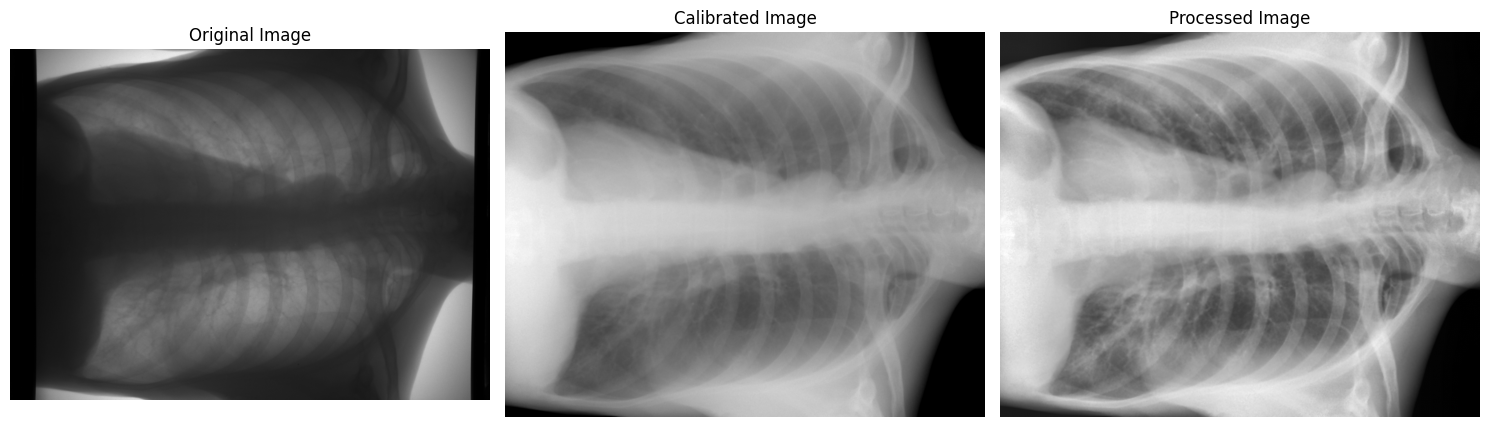

2026-04-01 17:12:13,462 - INFO - Cleaning up memory...
2026-04-01 17:12:13,548 - INFO - Memory cleaned.
2026-04-01 17:12:13,551 - INFO - Pipeline completed successfully.



FULL PIPELINE RESULTS
Best parameters: (10000, 1.5, 0.99, 2, 0.8, 3.0, (8, 8))
CII:         1.0000
Entropy:     10.7308
EME:         53.4017
Total Score: 65.1325


: 

In [ ]:
config.processing_mode = "full"
pipeline = ImageProcessingPipeline(config)
result_full = pipeline.process(show_plot=True)

print("\n" + "=" * 50)
print("FULL PIPELINE RESULTS")
print("=" * 50)
print(f"Best parameters: {result_full.parameters}")
print(f"CII:         {result_full.cii:.4f}")
print(f"Entropy:     {result_full.entropy:.4f}")
print(f"EME:         {result_full.eme:.4f}")
print(f"Total Score: {result_full.total_score:.4f}")

---
## 4. PACE Mode (BEMD + Enhancement only, no FFC / calibration)

Requires only: `proj_img_path`

In [ ]:
config.processing_mode = "pace"
pipeline_pace = ImageProcessingPipeline(config)
result_pace = pipeline_pace.process(show_plot=True, mode="pace")

print("\n" + "=" * 50)
print("PACE PIPELINE RESULTS")
print("=" * 50)
print(f"Best parameters: {result_pace.parameters}")
print(f"CII:         {result_pace.cii:.4f}")
print(f"Entropy:     {result_pace.entropy:.4f}")
print(f"EME:         {result_pace.eme:.4f}")
print(f"Total Score: {result_pace.total_score:.4f}")

---
## 5. Batch Processing - Full Pipeline

In [ ]:
#@title Batch settings (Full) { run: "auto" }

batch_input_dir = "datacitra/Thorax"  #@param {type:"string"}
batch_output_dir = "output"  #@param {type:"string"}

In [ ]:
config.processing_mode = "full"
pipeline_batch = ImageProcessingPipeline(config)

batch_results_full = []
for filename in os.listdir(batch_input_dir):
    if filename.lower().endswith((".tiff", ".tif", ".mdn")):
        print(f"\nProcessing: {filename}")
        p = os.path.join(batch_input_dir, filename)
        o = os.path.join(batch_output_dir, Path(filename).stem + "_processed.tiff")
        r = pipeline_batch.process(proj_path=p, output_path=o, show_plot=False)
        batch_results_full.append({"file": filename, "score": r.total_score, "params": r.parameters})

print("\n" + "=" * 50)
print("BATCH (FULL) SUMMARY")
print("=" * 50)
for r in batch_results_full:
    print(f"{r['file']}: Score = {r['score']:.4f}")

---
## 6. Batch Processing - PACE Mode

In [ ]:
#@title Batch settings (PACE) { run: "auto" }

pace_batch_input_dir = "datacitra/Thorax"  #@param {type:"string"}
pace_batch_output_dir = "output"  #@param {type:"string"}

In [ ]:
config.processing_mode = "pace"
pipeline_pace_batch = ImageProcessingPipeline(config)

batch_results_pace = []
for filename in os.listdir(pace_batch_input_dir):
    if filename.lower().endswith((".tiff", ".tif", ".mdn")):
        print(f"\nProcessing (PACE): {filename}")
        p = os.path.join(pace_batch_input_dir, filename)
        o = os.path.join(pace_batch_output_dir, Path(filename).stem + "_pace_processed.tiff")
        r = pipeline_pace_batch.process(proj_path=p, output_path=o, show_plot=False, mode="pace")
        batch_results_pace.append({"file": filename, "score": r.total_score, "params": r.parameters})

print("\n" + "=" * 50)
print("BATCH (PACE) SUMMARY")
print("=" * 50)
for r in batch_results_pace:
    print(f"{r['file']}: Score = {r['score']:.4f}")

---
## 7. Step-by-Step Processing (Full Pipeline)

Use this section when you need fine-grained control over each processing step.

In [ ]:
#@title Step-by-step: single-set filter params { run: "auto" }

step_proj_path = ""  #@param {type:"string"}
step_gain_path = "datacitra/Gain/Bed/80_50_0,50.mdn"  #@param {type:"string"}
step_dark_path = "datacitra/Dark/Bed/dark.mdn"  #@param {type:"string"}
step_calib_path = "datacitra/Kalibrasi/bed_44_35.npz"  #@param {type:"string"}

# Decomposition
step_decomposition = "fabemd"  #@param ["bemd", "fabemd"]

# Homomorphic filter
step_hom_method = "gaussian"  #@param ["gaussian", "butterworth"]
step_d0 = 30  #@param {type:"integer"}
step_rh = 2.0  #@param {type:"number"}
step_rl = 0.5  #@param {type:"number"}
step_gamma_h = 2.0  #@param {type:"number"}
step_gamma_l = 0.5  #@param {type:"number"}
step_bw_order = 2  #@param {type:"integer"}

# Denoising
step_denoise_method = "bilateral"  #@param ["bilateral", "nlmeans"]
step_nlmeans_h = 10.0  #@param {type:"number"}

# Enhancement
step_gamma = 0.8  #@param {type:"number"}
step_clip_limit = 3.0  #@param {type:"number"}
step_output_width = 4096  #@param {type:"integer"}

In [ ]:
# Step 1: Load images
print("Step 1: Loading images...")
proj_img = cv2.imread(step_proj_path, -1)
gain_img = cv2.imread(step_gain_path, -1)
dark_img = cv2.imread(step_dark_path, -1)

# Step 2: Flat Field Correction
print("Step 2: Applying Flat Field Correction...")
ffc = FlatFieldCorrection(median_filter_size=ffc_median_filter_size)
ffc_image = ffc.apply(proj_img, gain_img, dark_img)

# Step 3: Spatial Calibration
print("Step 3: Applying Spatial Calibration...")
calibrator = SpatialCalibration(step_calib_path)
calibrated_image = calibrator.apply(ffc_image)

# Step 4: Decomposition (BEMD or FABEMD)
print(f"Step 4: {step_decomposition.upper()} Decomposition...")
residue = None
if step_decomposition == "fabemd":
    decomposer = FABEMD(
        max_sift_iterations=fabemd_max_sift_iterations,
        sd_threshold=fabemd_sd_threshold,
        min_extrema=fabemd_min_extrema,
        max_bimfs=fabemd_max_bimfs,
        window_size_cap=fabemd_window_size_cap,
        extrema_window=fabemd_extrema_window,
        window_growth_rate=fabemd_window_growth_rate,
    )
    bimfs, residue = decomposer.decompose_with_residual(cp.asarray(calibrated_image))
    energies = FABEMD.calculate_energies(bimfs)
else:
    decomposer = BEMD(
        max_iterations=bemd_max_iterations,
        threshold=bemd_threshold,
        initial_window_size=bemd_initial_window_size,
        local_extrema_count=bemd_local_extrema_count,
    )
    bimfs = decomposer.decompose(cp.asarray(calibrated_image))
    energies = BEMD.calculate_energies(bimfs)

print(f"   Extracted {len(bimfs)} BIMFs")

# Step 5: Homomorphic Filter (Gaussian or Butterworth)
# Apply to residue (FABEMD) or calibrated image (BEMD)
hom_input = residue if residue is not None else calibrated_image
if hasattr(hom_input, 'get'):
    hom_input = hom_input.get()

print(f"Step 5: Applying {step_hom_method} Homomorphic Filter...")
if step_hom_method == "butterworth":
    hf = PACEHomomorphicFilter(d0=step_d0, gamma_h=step_gamma_h, gamma_l=step_gamma_l, n=step_bw_order)
else:
    hf = HomomorphicFilter(d0=step_d0, rh=step_rh, rl=step_rl)
filtered_image = hf.apply(hom_input)

# Step 6: Nonlinear Filter — Bilateral or NL-Means
print(f"Step 6: Denoising ({step_denoise_method})...")
if step_denoise_method == "nlmeans":
    nlf = NLMeansFilter(r=denoise_r, beta=denoise_beta, h=step_nlmeans_h)
else:
    nlf = NonlinearFilter(r=denoise_r, beta=denoise_beta)
denoised_image = nlf.denoise(bimfs, energies, filtered_image)

# Step 7: Gamma Correction
print("Step 7: Applying Gamma Correction...")
gamma_image = ImageEnhancer.gamma_correction(denoised_image, gamma=step_gamma)

# Step 8: CLAHE
print("Step 8: Applying CLAHE...")
clahe_image = ImageEnhancer.apply_clahe(gamma_image, clip_limit=step_clip_limit)

# Step 9: Metrics
print("Step 9: Calculating Metrics...")
mask = np.ones_like(calibrated_image)
cii = ImageMetrics.calculate_cii(clahe_image, calibrated_image, mask)
entropy = ImageMetrics.calculate_entropy(clahe_image)
eme = ImageMetrics.calculate_eme(clahe_image, 4, 4)

print(f"\nMetrics:")
print(f"  CII:     {cii:.4f}")
print(f"  Entropy: {entropy:.4f}")
print(f"  EME:     {eme:.4f}")

# Step 10: Resize and Save
print("Step 10: Resizing and saving...")
from image_pipeline import _to_numpy
final_image = _to_numpy(ImageResizer.resize(clahe_image, step_output_width))
os.makedirs("output", exist_ok=True)
cv2.imwrite("output/step_by_step.tiff", final_image.astype(np.uint16))

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(proj_img, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(calibrated_image, cmap="gray"); axes[1].set_title("Calibrated"); axes[1].axis("off")
axes[2].imshow(final_image, cmap="gray"); axes[2].set_title("Processed"); axes[2].axis("off")
plt.tight_layout()
plt.show()
print(f"\nProcessing complete! (decomp={step_decomposition}, hom={step_hom_method}, denoise={step_denoise_method})")

---
## 8. Load Configuration from JSON

If you prefer managing settings via `config.json`, use this cell instead of sections 2a-2d.

In [ ]:
json_config_path = "config.json"  #@param {type:"string"}

config_from_json = PipelineConfig.from_json(json_config_path)
print("Loaded config from JSON")
print(config_from_json)

In [ ]:
# Run full pipeline from JSON config
config_from_json.processing_mode = "full"  # change to "pace" for PACE mode

pipeline_json = ImageProcessingPipeline(config_from_json)
result_json = pipeline_json.process(show_plot=True)

print(f"\nBest parameters: {result_json.parameters}")
print(f"Total Score:     {result_json.total_score:.4f}")